# Extraction temporelle — comptes rendus médicaux (MTSamples)

Même modèle BERT appliqué sans adaptation au domaine à des comptes rendus d'urgences MTSamples annotés par Viani et al. (2019). Évaluation en correspondance **exacte** puis **souple** (chevauchement), avec export des comparaisons en SQLite et CSV. Adapter `text_folder` et `annotations_path` dans la dernière cellule.

### Imports

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import torch
import sqlite3
from transformers import pipeline

### Configuration gpu

In [ ]:
device = 0 if torch.cuda.is_available() else -1
print(f"🚀 Accélérateur : {'GPU ' + torch.cuda.get_device_name(0) if device == 0 else 'CPU'}")

### Extraction bert (identique à l'original)

In [ ]:
def extract_predictions_from_corpus(text_folder):
    """
    Extrait les prédictions BERT pour tous les fichiers du corpus
    """
    print("\n🤖 Démarrage du modèle Transformer...")
    model_name = "satyaalmasian/temporal_tagger_BERT_tokenclassifier"
    nlp = pipeline("token-classification", 
                   model=model_name, 
                   aggregation_strategy="simple", 
                   device=device, 
                   batch_size=32)
    
    all_predictions = []
    
    print(f"\n📂 Traitement des fichiers dans {text_folder}")
    for filename in os.listdir(text_folder):
        if not filename.endswith(".txt"):
            continue
        
        print(f"📄 Traitement de : {filename}")
        
        doc_path = os.path.join(text_folder, filename)
        with open(doc_path, "r", encoding="utf-8") as f:
            text = f.read()
        
        doc_name = filename
        sentences = nltk.sent_tokenize(text)
        cursor = 0
        
        for sentence in sentences:
            sentence_start = text.find(sentence, cursor)
            if sentence_start == -1:
                continue
            
            preds = nlp(sentence)
            
            for p in preds:
                global_start = sentence_start + p["start"]
                global_end = sentence_start + p["end"]
                
                all_predictions.append({
                    "doc_name": doc_name,
                    "text": p["word"],
                    "type": p["entity_group"].upper(),
                    "start": global_start,
                    "end": global_end,
                    "sentence": sentence,
                    "score": p.get("score", 1.0)
                })
            
            cursor = sentence_start + len(sentence)
    
    df_pred = pd.DataFrame(all_predictions)
    print(f"\n✅ {len(df_pred)} entités extraites par le modèle")
    print(f"📊 Distribution des types:\n{df_pred['type'].value_counts()}")
    
    return df_pred

### Chargement des annotations gold

In [ ]:
def load_gold_annotations(annotations_path):
    """
    Charge les annotations gold depuis le fichier d'annotations
    """
    print(f"\n📂 Chargement des annotations gold...")
    
    df = pd.read_csv(
        annotations_path,
        sep="\t",
        header=None,
        names=[
            "doc", "overlap",
            "text1", "text2",
            "type1", "type2",
            "val1", "val2",
            "start1", "end1",
            "start2", "end2",
            "sentence"
        ]
    )
    
    df["doc"] = df["doc"].astype(str).str.strip()
    
    # Nettoyage
    df_gold = df.dropna(subset=["text1", "type1", "start1", "end1"])
    df_gold = df_gold[~df_gold["type1"].isin(["other", "age_related"])].reset_index(drop=True)
    df_gold["start1"] = df_gold["start1"].astype(int)
    df_gold["end1"] = df_gold["end1"].astype(int)
    
    print(f"✅ {len(df_gold)} annotations gold chargées")
    print(f"📊 Distribution des types:\n{df_gold['type1'].value_counts()}")
    
    return df_gold

### Préparation des données pour évaluation

In [ ]:
def prepare_data_for_evaluation(df_pred, df_gold):
    """
    Prépare les DataFrames pour l'évaluation
    """
    print("\n🔧 Préparation des données pour évaluation...")
    
    # Normalisation des noms de documents
    df_pred["doc_name_clean"] = df_pred["doc_name"].str.replace(".txt", "", regex=False)
    
    # Normalisation des types
    type_mapping = {
        "TIME": "time",
        "DATE": "date",
        "DURATION": "duration",
        "SET": "frequency"
    }
    df_pred["type_normalized"] = df_pred["type"].map(type_mapping)
    
    # Vérification des documents communs
    docs_pred = set(df_pred["doc_name_clean"].unique())
    docs_gold = set(df_gold["doc"].unique())
    docs_common = docs_pred & docs_gold
    
    print(f"\n📊 Documents en commun : {len(docs_common)}")
    print(f"⚠️  Uniquement dans prédictions : {len(docs_pred - docs_gold)}")
    print(f"⚠️  Uniquement dans gold : {len(docs_gold - docs_pred)}")
    
    # Filtrage
    df_pred_filtered = df_pred[df_pred["doc_name_clean"].isin(docs_common)].copy()
    df_gold_filtered = df_gold[df_gold["doc"].isin(docs_common)].copy()
    
    print(f"\n✅ Après filtrage :")
    print(f"   Prédictions : {len(df_pred_filtered)} entités")
    print(f"   Gold : {len(df_gold_filtered)} entités")
    
    return df_pred_filtered, df_gold_filtered

### Fonction de matching améliorée pour la base de données

In [ ]:
def create_comprehensive_comparison_table(df_pred, df_gold, match_type="exact"):
    """
    Crée une table complète comparant les prédictions et le gold standard
    """
    print(f"\n🔍 Création de la table comparative (matching: {match_type})...")
    
    comparison_records = []
    matched_pred_indices = set()
    matched_gold_indices = set()
    
    # 1. Trouver les correspondances (TP)
    for idx_pred, pred_row in df_pred.iterrows():
        best_match = None
        best_overlap = 0
        
        for idx_gold, gold_row in df_gold.iterrows():
            if pred_row["doc_name_clean"] != gold_row["doc"]:
                continue
            
            pred_start, pred_end = pred_row["start"], pred_row["end"]
            gold_start1, gold_end1 = gold_row["start1"], gold_row["end1"]
            gold_start2 = gold_row.get("start2", gold_start1)
            gold_end2 = gold_row.get("end2", gold_end1)
            
            is_match = False
            overlap_score = 0
            
            if match_type == "exact":
                is_match = ((pred_start == gold_start1) and (pred_end == gold_end1)) or \
                           ((pred_start == gold_start2) and (pred_end == gold_end2))
                overlap_score = 1.0 if is_match else 0.0
            elif match_type == "overlap":
                # Calculer le chevauchement
                overlap_start = max(pred_start, min(gold_start1, gold_start2))
                overlap_end = min(pred_end, max(gold_end1, gold_end2))
                overlap_length = max(0, overlap_end - overlap_start)
                
                if overlap_length > 0:
                    is_match = True
                    pred_length = pred_end - pred_start
                    gold_length = max(gold_end1 - gold_start1, gold_end2 - gold_start2)
                    overlap_score = overlap_length / max(pred_length, gold_length)
            
            if is_match and overlap_score > best_overlap:
                best_overlap = overlap_score
                best_match = (idx_gold, gold_row, overlap_score)
        
        if best_match:
            idx_gold, gold_row, overlap_score = best_match
            matched_pred_indices.add(idx_pred)
            matched_gold_indices.add(idx_gold)
            
            type_match = (pred_row["type_normalized"] == gold_row["type1"])
            
            comparison_records.append({
                "id": len(comparison_records) + 1,
                "document": pred_row["doc_name_clean"],
                "status": "TP" if type_match else "TP_TYPE_ERROR",
                
                # Prédiction
                "pred_text": pred_row["text"],
                "pred_type": pred_row["type_normalized"],
                "pred_start": pred_row["start"],
                "pred_end": pred_row["end"],
                "pred_score": pred_row["score"],
                
                # Gold
                "gold_text": gold_row["text1"],
                "gold_type": gold_row["type1"],
                "gold_start": gold_row["start1"],
                "gold_end": gold_row["end1"],
                
                # Comparaison
                "type_match": type_match,
                "overlap_score": overlap_score,
                "sentence": pred_row["sentence"],
                "match_type": match_type
            })
    
    # 2. Ajouter les FP (prédictions sans correspondance)
    for idx_pred, pred_row in df_pred.iterrows():
        if idx_pred not in matched_pred_indices:
            comparison_records.append({
                "id": len(comparison_records) + 1,
                "document": pred_row["doc_name_clean"],
                "status": "FP",
                
                "pred_text": pred_row["text"],
                "pred_type": pred_row["type_normalized"],
                "pred_start": pred_row["start"],
                "pred_end": pred_row["end"],
                "pred_score": pred_row["score"],
                
                "gold_text": None,
                "gold_type": None,
                "gold_start": None,
                "gold_end": None,
                
                "type_match": False,
                "overlap_score": 0.0,
                "sentence": pred_row["sentence"],
                "match_type": match_type
            })
    
    # 3. Ajouter les FN (gold sans correspondance)
    for idx_gold, gold_row in df_gold.iterrows():
        if idx_gold not in matched_gold_indices:
            comparison_records.append({
                "id": len(comparison_records) + 1,
                "document": gold_row["doc"],
                "status": "FN",
                
                "pred_text": None,
                "pred_type": None,
                "pred_start": None,
                "pred_end": None,
                "pred_score": None,
                
                "gold_text": gold_row["text1"],
                "gold_type": gold_row["type1"],
                "gold_start": gold_row["start1"],
                "gold_end": gold_row["end1"],
                
                "type_match": False,
                "overlap_score": 0.0,
                "sentence": gold_row.get("sentence", ""),
                "match_type": match_type
            })
    
    df_comparison = pd.DataFrame(comparison_records)
    
    print(f"✅ Table créée avec {len(df_comparison)} entrées:")
    print(f"   - TP (Correct): {len(df_comparison[df_comparison['status'] == 'TP'])}")
    print(f"   - TP_TYPE_ERROR: {len(df_comparison[df_comparison['status'] == 'TP_TYPE_ERROR'])}")
    print(f"   - FP (Faux Positifs): {len(df_comparison[df_comparison['status'] == 'FP'])}")
    print(f"   - FN (Faux Négatifs): {len(df_comparison[df_comparison['status'] == 'FN'])}")
    
    return df_comparison

### Création de la base de données sqlite

In [ ]:
def create_database(df_comparison, db_name="temporal_extraction_results.db"):
    """
    Crée une base de données SQLite avec les résultats comparatifs
    """
    print(f"\n💾 Création de la base de données: {db_name}")
    
    # Supprimer l'ancienne base si elle existe
    if os.path.exists(db_name):
        os.remove(db_name)
        print(f"   ℹ️  Ancienne base supprimée")
    
    # Créer la connexion
    conn = sqlite3.connect(db_name)
    
    # Créer la table
    df_comparison.to_sql('comparison_results', conn, if_exists='replace', index=False)
    
    # Créer des index pour améliorer les performances des requêtes
    cursor = conn.cursor()
    cursor.execute("""
        CREATE INDEX IF NOT EXISTS idx_document ON comparison_results(document)
    """)
    cursor.execute("""
        CREATE INDEX IF NOT EXISTS idx_status ON comparison_results(status)
    """)
    cursor.execute("""
        CREATE INDEX IF NOT EXISTS idx_pred_type ON comparison_results(pred_type)
    """)
    cursor.execute("""
        CREATE INDEX IF NOT EXISTS idx_gold_type ON comparison_results(gold_type)
    """)
    
    conn.commit()
    
    # Afficher des statistiques
    print(f"\n✅ Base de données créée avec succès!")
    print(f"\n📊 Statistiques de la base:")
    
    # Statistiques par status
    status_stats = pd.read_sql_query("""
        SELECT status, COUNT(*) as count
        FROM comparison_results
        GROUP BY status
        ORDER BY count DESC
    """, conn)
    print("\n   📈 Par statut:")
    print(status_stats.to_string(index=False))
    
    # Statistiques par document
    doc_stats = pd.read_sql_query("""
        SELECT document, 
               COUNT(*) as total,
               SUM(CASE WHEN status = 'TP' THEN 1 ELSE 0 END) as tp,
               SUM(CASE WHEN status = 'FP' THEN 1 ELSE 0 END) as fp,
               SUM(CASE WHEN status = 'FN' THEN 1 ELSE 0 END) as fn
        FROM comparison_results
        GROUP BY document
        ORDER BY total DESC
        LIMIT 10
    """, conn)
    print("\n   📄 Top 10 documents (par nombre d'entités):")
    print(doc_stats.to_string(index=False))
    
    # Statistiques par type
    type_stats = pd.read_sql_query("""
        SELECT 
            COALESCE(pred_type, gold_type) as type,
            SUM(CASE WHEN status = 'TP' THEN 1 ELSE 0 END) as tp,
            SUM(CASE WHEN status = 'TP_TYPE_ERROR' THEN 1 ELSE 0 END) as tp_type_error,
            SUM(CASE WHEN status = 'FP' THEN 1 ELSE 0 END) as fp,
            SUM(CASE WHEN status = 'FN' THEN 1 ELSE 0 END) as fn
        FROM comparison_results
        GROUP BY type
        ORDER BY (tp + tp_type_error + fp + fn) DESC
    """, conn)
    print("\n   🏷️  Par type d'entité:")
    print(type_stats.to_string(index=False))
    
    conn.close()
    
    print(f"\n💡 Requêtes SQL utiles:")
    print(f"   -- Voir tous les TP corrects:")
    print(f"   SELECT * FROM comparison_results WHERE status = 'TP';")
    print(f"\n   -- Voir tous les FP (faux positifs):")
    print(f"   SELECT * FROM comparison_results WHERE status = 'FP';")
    print(f"\n   -- Voir tous les FN (faux négatifs):")
    print(f"   SELECT * FROM comparison_results WHERE status = 'FN';")
    print(f"\n   -- Voir les erreurs de classification:")
    print(f"   SELECT * FROM comparison_results WHERE status = 'TP_TYPE_ERROR';")
    print(f"\n   -- Statistiques par document:")
    print(f"   SELECT document, status, COUNT(*) FROM comparison_results GROUP BY document, status;")
    
    return db_name

### Fonction d'export csv (optionnel)

In [ ]:
def export_to_csv(df_comparison, csv_name="temporal_extraction_results.csv"):
    """
    Exporte également les résultats en CSV pour une visualisation facile dans Excel
    """
    print(f"\n📊 Export CSV: {csv_name}")
    df_comparison.to_csv(csv_name, index=False, encoding='utf-8')
    print(f"✅ Export CSV terminé!")
    return csv_name

### Fonction de matching (version simplifiée pour métriques)

In [ ]:
def calculate_metrics_from_comparison(df_comparison):
    """
    Calcule les métriques à partir de la table de comparaison
    """
    tp = len(df_comparison[df_comparison['status'] == 'TP'])
    tp_type_error = len(df_comparison[df_comparison['status'] == 'TP_TYPE_ERROR'])
    fp = len(df_comparison[df_comparison['status'] == 'FP'])
    fn = len(df_comparison[df_comparison['status'] == 'FN'])
    
    # Métriques de détection
    tp_detection = tp + tp_type_error
    precision_detection = tp_detection / (tp_detection + fp) if (tp_detection + fp) > 0 else 0
    recall_detection = tp_detection / (tp_detection + fn) if (tp_detection + fn) > 0 else 0
    f1_detection = 2 * (precision_detection * recall_detection) / (precision_detection + recall_detection) \
                   if (precision_detection + recall_detection) > 0 else 0
    
    # Métriques de classification
    tp_classif = tp
    precision_classif = tp_classif / (tp_classif + tp_type_error + fp) if (tp_classif + tp_type_error + fp) > 0 else 0
    recall_classif = tp_classif / (tp_classif + fn) if (tp_classif + fn) > 0 else 0
    f1_classif = 2 * (precision_classif * recall_classif) / (precision_classif + recall_classif) \
                 if (precision_classif + recall_classif) > 0 else 0
    
    print(f"\n🔍 MÉTRIQUES DE DÉTECTION")
    print("=" * 60)
    print(f"  ✅ True Positives (TP)  : {tp_detection}")
    print(f"  ❌ False Positives (FP) : {fp}")
    print(f"  ⚠️  False Negatives (FN) : {fn}")
    print(f"\n📈 Scores :")
    print(f"  🎯 Precision : {precision_detection:.3f} ({precision_detection*100:.1f}%)")
    print(f"  🎯 Recall    : {recall_detection:.3f} ({recall_detection*100:.1f}%)")
    print(f"  🎯 F1-Score  : {f1_detection:.3f} ({f1_detection*100:.1f}%)")
    
    print(f"\n\n🏷️  MÉTRIQUES DE CLASSIFICATION")
    print("=" * 60)
    print(f"  ✅ Détection + Type correct : {tp}")
    print(f"  ⚠️  Détection mais type incorrect : {tp_type_error}")
    print(f"\n📈 Scores :")
    print(f"  🎯 Precision : {precision_classif:.3f} ({precision_classif*100:.1f}%)")
    print(f"  🎯 Recall    : {recall_classif:.3f} ({recall_classif*100:.1f}%)")
    print(f"  🎯 F1-Score  : {f1_classif:.3f} ({f1_classif*100:.1f}%)")
    
    return (precision_detection, recall_detection, f1_detection), \
           (precision_classif, recall_classif, f1_classif)

### Visualisation graphique

In [ ]:
def plot_comprehensive_statistics(df_gold, df_pred, dataset_name, det_scores, clf_scores):
    """
    Génère les visualisations graphiques
    """
    print("\n📈 Génération des graphiques...")
    
    fig = plt.figure(figsize=(18, 10))
    
    # Graphique 1: Distribution des types
    ax1 = plt.subplot(2, 3, 1)
    data_dict = {}
    if not df_gold.empty:
        data_dict['Gold'] = df_gold['type1'].value_counts()
    if not df_pred.empty:
        data_dict['Prédit'] = df_pred['type_normalized'].value_counts()
    
    df_plot = pd.DataFrame(data_dict).fillna(0)
    if not df_plot.empty:
        df_plot.plot(kind='bar', ax=ax1, color=['#2ecc71', '#3498db'])
        ax1.set_title("Distribution des Types d'Entités", fontsize=12, fontweight='bold')
        ax1.set_xlabel("Type")
        ax1.set_ylabel("Nombre")
        ax1.legend(loc='best')
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Graphique 2: Scores de détection
    ax2 = plt.subplot(2, 3, 2)
    det_metrics = ['Précision', 'Rappel', 'F1-Score']
    det_values = [det_scores[0], det_scores[1], det_scores[2]]
    colors = ['#e74c3c', '#f39c12', '#9b59b6']
    bars = ax2.bar(det_metrics, det_values, color=colors, alpha=0.7)
    ax2.set_title("Scores de Détection d'Entités", fontsize=12, fontweight='bold')
    ax2.set_ylabel("Score")
    ax2.set_ylim(0, 1)
    for bar, val in zip(bars, det_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1%}', ha='center', va='bottom', fontweight='bold')
    
    # Graphique 3: Scores de classification
    ax3 = plt.subplot(2, 3, 3)
    clf_metrics = ['Précision', 'Rappel', 'F1-Score']
    clf_values = [clf_scores[0], clf_scores[1], clf_scores[2]]
    bars = ax3.bar(clf_metrics, clf_values, color=colors, alpha=0.7)
    ax3.set_title("Scores de Classification des Types", fontsize=12, fontweight='bold')
    ax3.set_ylabel("Score")
    ax3.set_ylim(0, 1)
    for bar, val in zip(bars, clf_values):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1%}', ha='center', va='bottom', fontweight='bold')
    
    # Graphique 4: Distribution des scores de confiance
    ax4 = plt.subplot(2, 3, 4)
    if not df_pred.empty and 'score' in df_pred.columns:
        sns.histplot(df_pred['score'], bins=15, kde=True, color='#8e44ad', ax=ax4)
        ax4.set_title("Distribution des Scores de Confiance", fontsize=12, fontweight='bold')
        ax4.set_xlabel("Score de Confiance")
        ax4.set_ylabel("Fréquence")
    
    # Graphique 5: Comparaison Détection vs Classification
    ax5 = plt.subplot(2, 3, 5)
    comparison_data = {
        'Détection': det_values,
        'Classification': clf_values
    }
    df_comparison = pd.DataFrame(comparison_data, index=det_metrics)
    df_comparison.plot(kind='bar', ax=ax5, color=['#16a085', '#d35400'])
    ax5.set_title("Comparaison Détection vs Classification", fontsize=12, fontweight='bold')
    ax5.set_ylabel("Score")
    ax5.set_ylim(0, 1)
    ax5.legend(loc='best')
    plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Graphique 6: Matrice de confusion simplifiée
    ax6 = plt.subplot(2, 3, 6)
    if not df_gold.empty and not df_pred.empty:
        tp = det_scores[0] * len(df_pred) if det_scores[0] > 0 else 0
        fp = len(df_pred) - tp
        fn = len(df_gold) - tp
        tn = 0
        
        confusion_data = [[tp, fp], [fn, tn]]
        sns.heatmap(confusion_data, annot=True, fmt='.0f', cmap='Blues', ax=ax6,
                   xticklabels=['Positif', 'Négatif'],
                   yticklabels=['Vrai', 'Faux'])
        ax6.set_title("Matrice de Confusion (Détection)", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    output_path = f'stats_{dataset_name}.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"✅ Graphiques sauvegardés: {output_path}")
    plt.show()

### Pipeline principal modifié

In [ ]:
def run_medical_pipeline_with_db(text_folder, annotations_path, match_type="exact", db_name=None):
    """
    Pipeline complet avec génération de base de données
    """
    print("\n" + "=" * 80)
    print(f"🚀 PIPELINE D'EXTRACTION TEMPORELLE - MEDICAL (Matching: {match_type.upper()})")
    print("=" * 80)
    
    # 1. Extraction BERT
    df_pred = extract_predictions_from_corpus(text_folder)
    
    # 2. Chargement gold
    df_gold = load_gold_annotations(annotations_path)
    
    # 3. Préparation
    df_pred_filtered, df_gold_filtered = prepare_data_for_evaluation(df_pred, df_gold)
    
    # 4. Création de la table comparative complète
    df_comparison = create_comprehensive_comparison_table(
        df_pred_filtered, df_gold_filtered, match_type=match_type
    )
    
    # 5. Calcul des métriques
    det_scores, clf_scores = calculate_metrics_from_comparison(df_comparison)
    
    # 6. Création de la base de données
    if db_name is None:
        db_name = f"temporal_extraction_{match_type}.db"
    db_path = create_database(df_comparison, db_name)
    
    # 7. Export CSV (optionnel)
    csv_path = export_to_csv(df_comparison, db_name.replace('.db', '.csv'))
    
    # 8. Visualisation
    plot_comprehensive_statistics(df_gold_filtered, df_pred_filtered, 
                                  f"medical_{match_type}", det_scores, clf_scores)
    
    print("\n" + "=" * 80)
    print("✅ PIPELINE TERMINÉ")
    print(f"💾 Base de données: {db_path}")
    print(f"📊 Fichier CSV: {csv_path}")
    print("=" * 80)
    
    return {
        'detection': {'precision': det_scores[0], 'recall': det_scores[1], 'f1': det_scores[2]},
        'classification': {'precision': clf_scores[0], 'recall': clf_scores[1], 'f1': clf_scores[2]},
        'df_gold': df_gold_filtered,
        'df_pred': df_pred_filtered,
        'df_comparison': df_comparison,
        'db_path': db_path,
        'csv_path': csv_path
    }

### Exécution

2026-01-04 16:51:02.617628: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767545462.815861      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767545462.868813      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767545463.342465      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767545463.342497      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767545463.342500      55 computation_placer.cc:177] computation placer alr

🚀 Accélérateur : GPU Tesla P100-PCIE-16GB

🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴
ÉVALUATION AVEC MATCHING EXACT (STRICT)
🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴

🚀 PIPELINE D'EXTRACTION TEMPORELLE - MEDICAL (Matching: EXACT)

🤖 Démarrage du modèle Transformer...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0



📂 Traitement des fichiers dans /kaggle/input/emergency/corpus/corpus
📄 Traitement de : 949-closedheadinjury.txt


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


📄 Traitement de : 1257-anklepain.txt
📄 Traitement de : 780-erreport-chestpain.txt
📄 Traitement de : 1371-difficultybreathing-ervisit.txt
📄 Traitement de : 1256-footpain.txt
📄 Traitement de : 102-consult-icumanagement.txt
📄 Traitement de : 2757-antbaitexposure-ervisit.txt
📄 Traitement de : 951-chesttubeinsertioniner.txt
📄 Traitement de : 2452-urgentcardiaccath.txt
📄 Traitement de : 2327-hydrocarbonaspiration-ervisit.txt
📄 Traitement de : 1294-alteredmentalstatus-ervisit.txt
📄 Traitement de : 1568-erreport-chestpainfever.txt
📄 Traitement de : 2758-agitation-ervisit.txt
📄 Traitement de : 1402-penileinjury.txt
📄 Traitement de : 2751-toothache-ervisit.txt
📄 Traitement de : 1401-hepaticencephalopathy.txt
📄 Traitement de : 1258-motorvehicleaccident.txt
📄 Traitement de : 2749-ecstasyingestion-ervisit.txt
📄 Traitement de : 942-headache-urgentcarevisit.txt
📄 Traitement de : 2746-notfeelingwell-ervisit.txt
📄 Traitement de : 2294-abrasionslacerations-ervisit.txt
📄 Traitement de : 1260-dentalpain-e

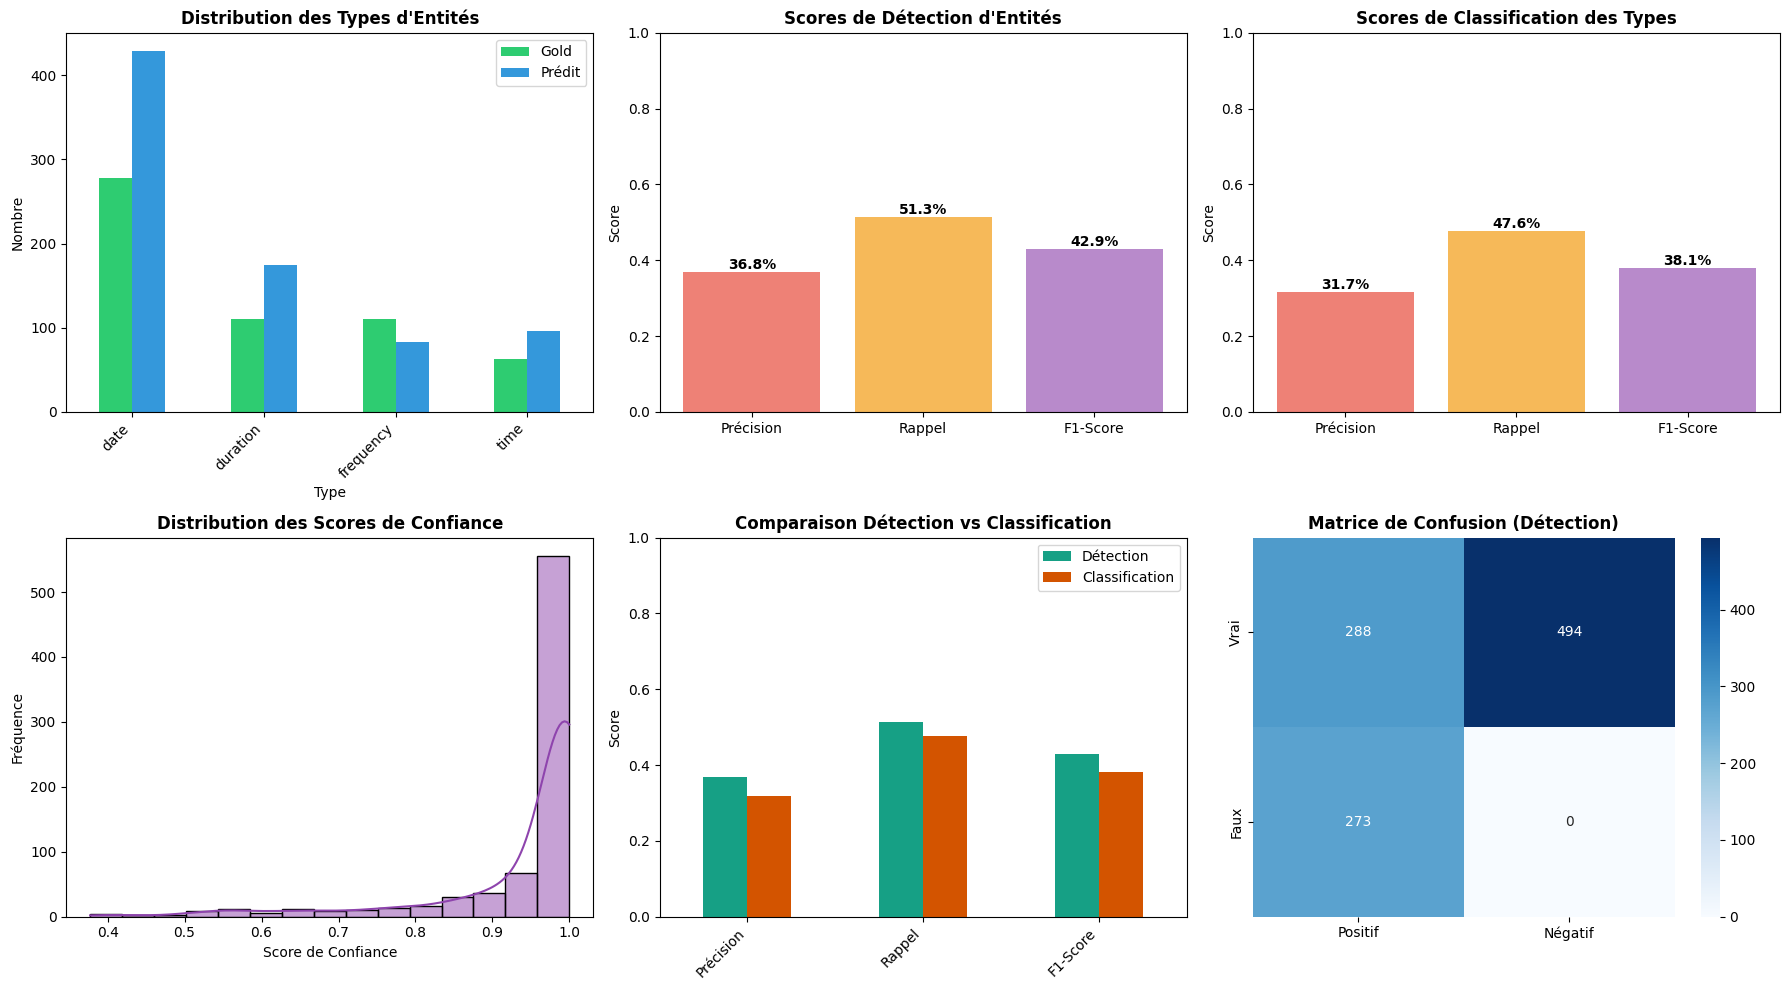


✅ PIPELINE TERMINÉ
💾 Base de données: temporal_extraction_exact.db
📊 Fichier CSV: temporal_extraction_exact.csv


🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢
ÉVALUATION AVEC MATCHING SOUPLE (OVERLAP)
🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢

🚀 PIPELINE D'EXTRACTION TEMPORELLE - MEDICAL (Matching: OVERLAP)

🤖 Démarrage du modèle Transformer...


Device set to use cuda:0



📂 Traitement des fichiers dans /kaggle/input/emergency/corpus/corpus
📄 Traitement de : 949-closedheadinjury.txt
📄 Traitement de : 1257-anklepain.txt
📄 Traitement de : 780-erreport-chestpain.txt
📄 Traitement de : 1371-difficultybreathing-ervisit.txt
📄 Traitement de : 1256-footpain.txt
📄 Traitement de : 102-consult-icumanagement.txt
📄 Traitement de : 2757-antbaitexposure-ervisit.txt
📄 Traitement de : 951-chesttubeinsertioniner.txt
📄 Traitement de : 2452-urgentcardiaccath.txt
📄 Traitement de : 2327-hydrocarbonaspiration-ervisit.txt
📄 Traitement de : 1294-alteredmentalstatus-ervisit.txt
📄 Traitement de : 1568-erreport-chestpainfever.txt
📄 Traitement de : 2758-agitation-ervisit.txt
📄 Traitement de : 1402-penileinjury.txt
📄 Traitement de : 2751-toothache-ervisit.txt
📄 Traitement de : 1401-hepaticencephalopathy.txt
📄 Traitement de : 1258-motorvehicleaccident.txt
📄 Traitement de : 2749-ecstasyingestion-ervisit.txt
📄 Traitement de : 942-headache-urgentcarevisit.txt
📄 Traitement de : 2746-notfe

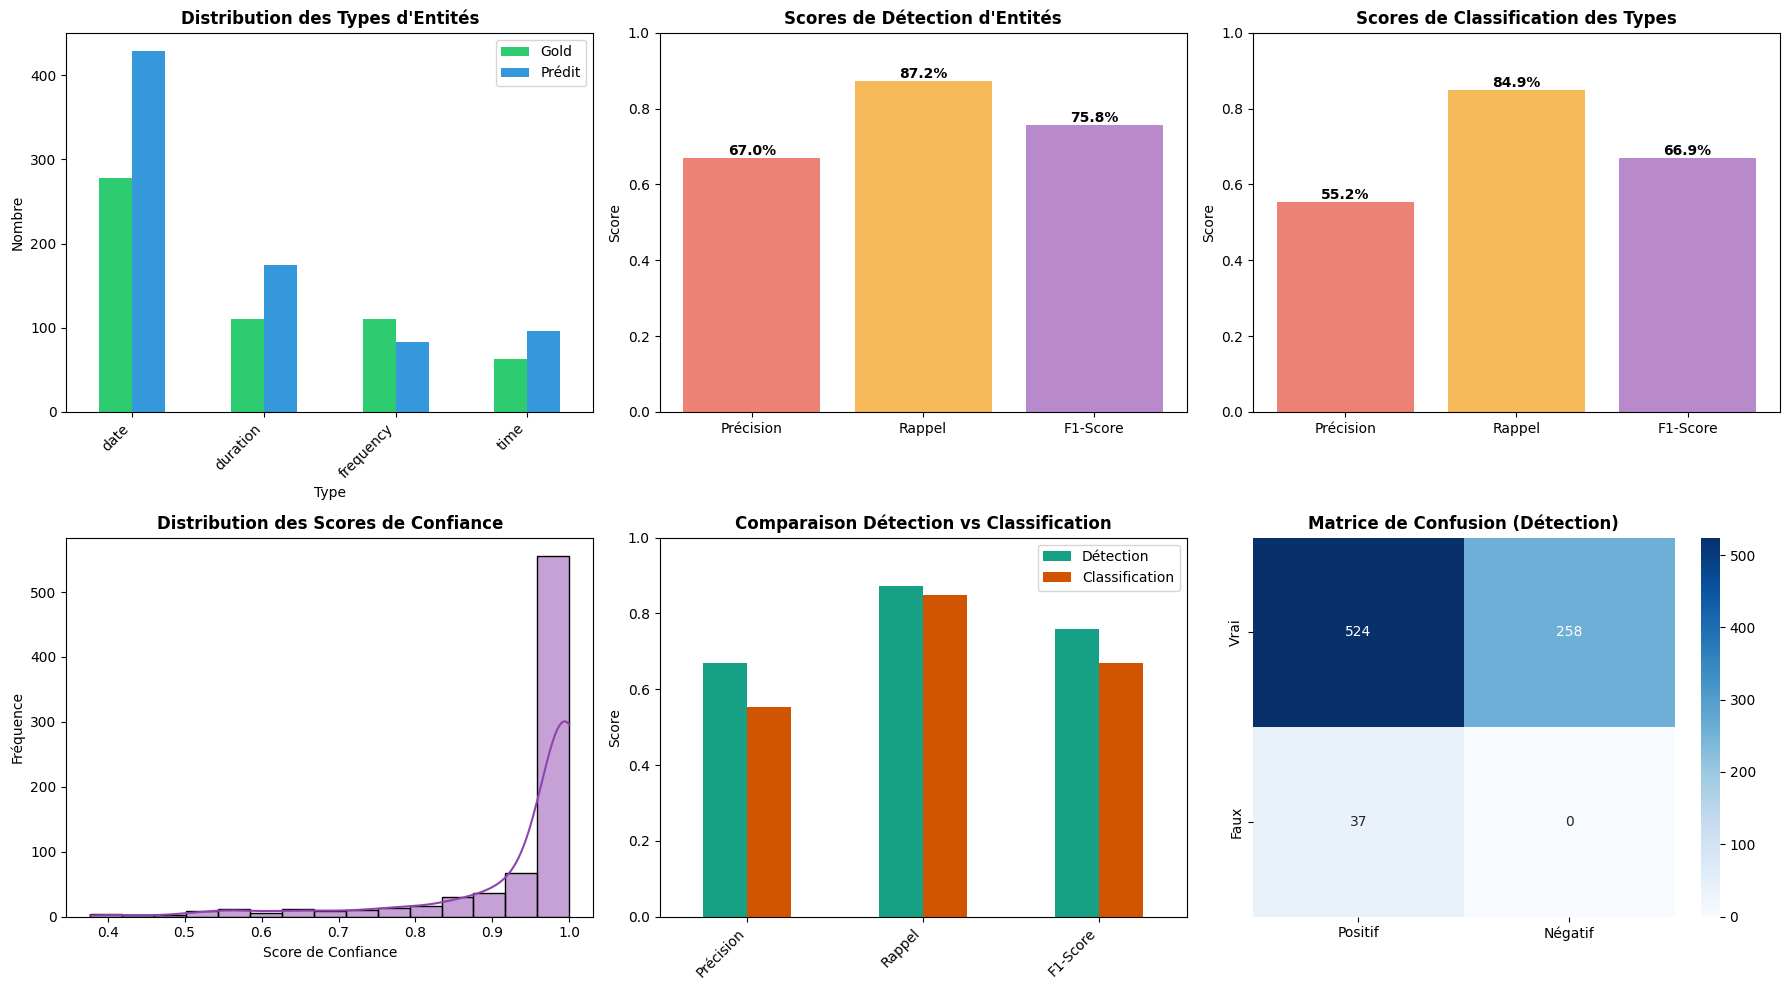


✅ PIPELINE TERMINÉ
💾 Base de données: temporal_extraction_overlap.db
📊 Fichier CSV: temporal_extraction_overlap.csv

📊 COMPARAISON EXACT vs OVERLAP

Métrique                       EXACT                OVERLAP
--------------------------------------------------------------------------------
Détection F1                   0.429 (42.9%)        0.758 (75.8%)
Classification F1              0.381 (38.1%)        0.669 (66.9%)

📂 FICHIERS GÉNÉRÉS
✅ Base de données (exact):   temporal_extraction_exact.db
✅ CSV (exact):              temporal_extraction_exact.csv
✅ Base de données (overlap): temporal_extraction_overlap.db
✅ CSV (overlap):            temporal_extraction_overlap.csv


In [ ]:
# Chemins à configurer
text_folder = "/kaggle/input/emergency/corpus/corpus"
annotations_path = "/kaggle/input/emergency/all_annotations.txt"

# ÉVALUATION STRICTE (exact match)
print("\n" + "🔴" * 40)
print("ÉVALUATION AVEC MATCHING EXACT (STRICT)")
print("🔴" * 40)
results_exact = run_medical_pipeline_with_db(
    text_folder, 
    annotations_path, 
    match_type="exact",
    db_name="temporal_extraction_exact.db"
)

# ÉVALUATION SOUPLE (overlap/fuzzy)
print("\n\n" + "🟢" * 40)
print("ÉVALUATION AVEC MATCHING SOUPLE (OVERLAP)")
print("🟢" * 40)
results_overlap = run_medical_pipeline_with_db(
    text_folder, 
    annotations_path, 
    match_type="overlap",
    db_name="temporal_extraction_overlap.db"
)

# Comparaison finale
if results_exact and results_overlap:
    print("\n" + "=" * 80)
    print("📊 COMPARAISON EXACT vs OVERLAP")
    print("=" * 80)
    print(f"\n{'Métrique':<30} {'EXACT':<20} {'OVERLAP'}")
    print("-" * 80)
    print(f"{'Détection F1':<30} {results_exact['detection']['f1']:.3f} ({results_exact['detection']['f1']*100:.1f}%)        {results_overlap['detection']['f1']:.3f} ({results_overlap['detection']['f1']*100:.1f}%)")
    print(f"{'Classification F1':<30} {results_exact['classification']['f1']:.3f} ({results_exact['classification']['f1']*100:.1f}%)        {results_overlap['classification']['f1']:.3f} ({results_overlap['classification']['f1']*100:.1f}%)")

    print("\n" + "=" * 80)
    print("📂 FICHIERS GÉNÉRÉS")
    print("=" * 80)
    print(f"✅ Base de données (exact):   {results_exact['db_path']}")
    print(f"✅ CSV (exact):              {results_exact['csv_path']}")
    print(f"✅ Base de données (overlap): {results_overlap['db_path']}")
    print(f"✅ CSV (overlap):            {results_overlap['csv_path']}")